1. Configuración del Entorno y Carga de Datos
En esta sección, importamos las librerías esenciales para la manipulación de datos (pandas, numpy) y la visualización (matplotlib). También vinculamos Google Drive para acceder al dataset de manera persistente.

In [ ]:
import os
import numpy as np
import pandas as pd # <-- La pieza clave para el dataset grande
from matplotlib import pyplot

**El objetivo es construir un modelo de Regresión Lineal Multivariable para predecir el precio de una vivienda** basándonos en múltiples características (variables independientes) como el número de habitaciones, metros cuadrados de construcción, ubicación (latitud/longitud), año de construcción, entre otros. Al tener más de una variable de entrada, el modelo busca encontrar la relación matemática óptima que mejor se ajuste a estos datos para realizar predicciones precisas sobre el valor de mercado de una propiedad.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cargamos el archivo CSV y realizamos una inspección inicial. Es fundamental entender la estructura de las variables (columnas) y verificar si existen valores nulos que puedan afectar el entrenamiento del modelo.
Eliminación de los duplicados Borramos registros idénticos que podrían sesgar el entrenamiento.

Eliminamos los IDs Quitamos la columna id ya que es un identificador administrativo que no aporta valor predictivo al precio.
La columna date es un texto complejo. La transformamos para extraer únicamente el año de la venta, convirtiéndola en un valor numérico útil para el cálculo matemático.


In [ ]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/sis420/Laboratorios/Lab 1/kc_house_data.csv')
duplicados = df.duplicated().sum()
print(f"Hay {duplicados} filas repetidas en el dataset.")
# Elimina los duplicados
df.drop_duplicates(inplace=True)

# Verificamos que se hayan borrado
print(f"Ahora hay {df.duplicated().sum()} filas repetidas.")
print(df.isnull().sum())
# 1. Eliminamos 'id' porque no ayuda a predecir el precio
df = df.drop(columns=['id'])

# 2. La columna 'date' es un string (ej. 20141013T000000).
# Para que la regresión lineal funcione, la convertiremos a un número simple (solo el año).
df['date'] = pd.to_datetime(df['date']).dt.year

# 3. Verificamos la forma del dataset
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.columns

Hay 0 filas repetidas en el dataset.
Ahora hay 0 filas repetidas.
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64
Filas: 21613, Columnas: 20


Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

Aquí dividimos nuestra tabla de datos en dos entidades fundamentales de NumPy:

Matriz X: Contiene todas las variables explicativas (columnas como metros cuadrados, pisos, etc.).

Vector y: Contiene la variable que deseamos predecir (el precio).
Obtenemos también las dimensiones de nuestros datos: m (número de casas en el dataset) y n (número de características por casa).

In [ ]:

X = df.drop(columns=['price']).values
y = df['price'].values
m = y.size
n = X.shape[1]
print(f"La matriz X tiene un tamaño de: {X.shape}")
print(X)
print(f"El vector y tiene un tamaño de: {y.shape}")
print(y)

La matriz X tiene un tamaño de: (21613, 19)
[[ 2.01400e+03  3.00000e+00  1.00000e+00 ... -1.22257e+02  1.34000e+03
   5.65000e+03]
 [ 2.01400e+03  3.00000e+00  2.25000e+00 ... -1.22319e+02  1.69000e+03
   7.63900e+03]
 [ 2.01500e+03  2.00000e+00  1.00000e+00 ... -1.22233e+02  2.72000e+03
   8.06200e+03]
 ...
 [ 2.01400e+03  2.00000e+00  7.50000e-01 ... -1.22299e+02  1.02000e+03
   2.00700e+03]
 [ 2.01500e+03  3.00000e+00  2.50000e+00 ... -1.22069e+02  1.41000e+03
   1.28700e+03]
 [ 2.01400e+03  2.00000e+00  7.50000e-01 ... -1.22299e+02  1.02000e+03
   1.35700e+03]]
El vector y tiene un tamaño de: (21613,)
[221900. 538000. 180000. ... 402101. 400000. 325000.]


Dado que las variables tienen rangos muy distintos (ej. número de habitaciones vs. pies cuadrados), aplicamos Normalización. Esto ayuda a que el Gradiente del Descendiente converja mucho más rápido, evitando que el modelo se sesgue hacia las variables con magnitudes más grandes.La fórmula utilizada es:$$z = \frac{x - \mu}{\sigma}$$Donde $\mu$ es la media y $\sigma$ la desviación estándar.

In [ ]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()

    # Verificamos si es un vector 1D (como 'y')
    if len(X.shape) == 1:
        mu = np.mean(X)
        sigma = np.std(X)
        X_norm = (X - mu) / sigma
        return X_norm, mu, sigma

    # Si es una matriz 2D (como 'X'), hace lo que ya tenías:
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    for i in range(X.shape[1]):
        mu[i] = np.mean(X[:, i])
        sigma[i] = np.std(X[:, i])
        X_norm[:, i] = (X[:, i] - mu[i]) / sigma[i]

    return X_norm, mu, sigma

In [ ]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = normalizarCaracteristicas(X)
y_norm,muy,sigmay=normalizarCaracteristicas(y)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print('matriz x normalizada',X_norm)
print(y)
print('Media calculada:', muy)
print('Desviación estandar calculada:', sigmay)
print('vector y normalizada',y_nomr)

[[ 2.01400e+03  3.00000e+00  1.00000e+00 ... -1.22257e+02  1.34000e+03
   5.65000e+03]
 [ 2.01400e+03  3.00000e+00  2.25000e+00 ... -1.22319e+02  1.69000e+03
   7.63900e+03]
 [ 2.01500e+03  2.00000e+00  1.00000e+00 ... -1.22233e+02  2.72000e+03
   8.06200e+03]
 ...
 [ 2.01400e+03  2.00000e+00  7.50000e-01 ... -1.22299e+02  1.02000e+03
   2.00700e+03]
 [ 2.01500e+03  3.00000e+00  2.50000e+00 ... -1.22069e+02  1.41000e+03
   1.28700e+03]
 [ 2.01400e+03  2.00000e+00  7.50000e-01 ... -1.22299e+02  1.02000e+03
   1.35700e+03]]
Media calculada: [ 2.01432295e+03  3.37084162e+00  2.11475732e+00  2.07989974e+03
  1.51069676e+04  1.49430898e+00  7.54175728e-03  2.34303428e-01
  3.40942951e+00  7.65687318e+00  1.78839069e+03  2.91509045e+02
  1.97100514e+03  8.44022579e+01  9.80779398e+04  4.75600525e+01
 -1.22213896e+02  1.98655249e+03  1.27684557e+04]
Desviación estandar calculada: [4.67605213e-01 9.30040315e-01 7.70145340e-01 9.18419649e+02
 4.14195533e+04 5.39976403e-01 8.65151962e-02 7.66299

Para entender la relación entre las características de las casas y su precio, es fundamental visualizar los datos. Esta función automatiza la creación de diagramas de dispersión (scatter plots) utilizando la librería matplotlib.

Al ejecutarla, se genera una figura donde cada punto rojo ('ro') representa una propiedad del dataset. Esto nos permite identificar visualmente si existe una tendencia lineal (por ejemplo, si a mayor número de metros cuadrados el precio sube de forma constante) o si existen valores atípicos (outliers) que podrían afectar el rendimiento de nuestro modelo de regresió

In [ ]:
def graficarDatos(x, y, xlabel, ylabel):
  fig = pyplot.figure()
  pyplot.plot(x, y, 'ro')
  pyplot.xlabel(xlabel)
  pyplot.ylabel(ylabel)

En esta etapa del proyecto, generamos tres gráficos distintos para analizar cómo se comportan nuestras variables tras la normalización:

Dormitorios vs. Precio: Nos permite observar si un mayor número de habitaciones incrementa linealmente el valor de la propiedad.

Baños vs. Precio: Similar al anterior, pero evaluando el impacto de los servicios sanitarios en el costo final.

Dormitorios vs. Baños: Este gráfico es interesante porque nos permite ver la correlación entre variables independientes. Por lo general, casas con más cuartos suelen tener más baños; si estos puntos forman una línea clara, indica que existe una relación fuerte entre ellas.

Estas visualizaciones son nuestra primera "prueba de realidad" antes de que el algoritmo de aprendizaje empiece a calcular los pesos óptimos.

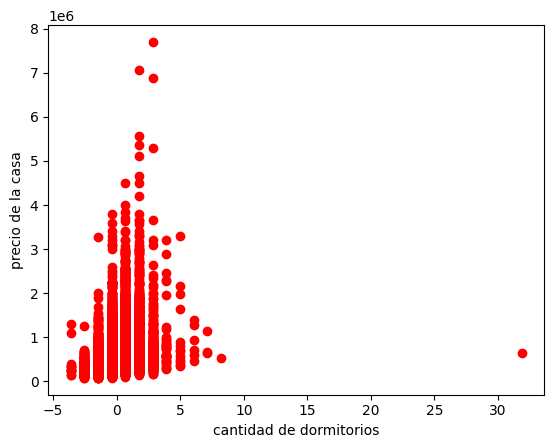

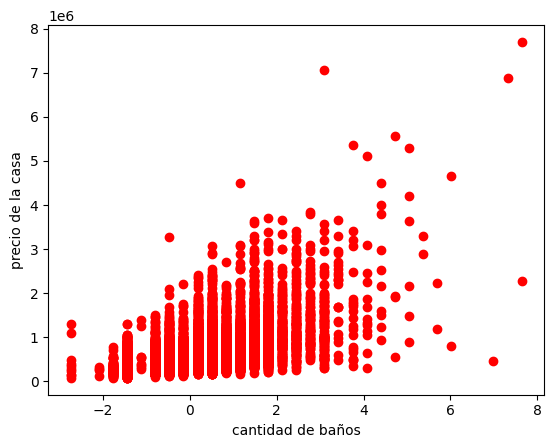

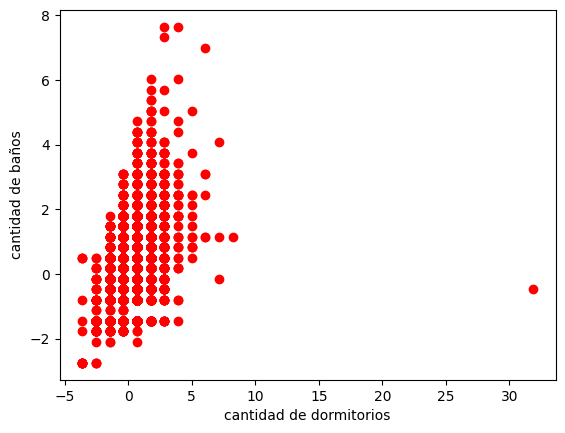

In [ ]:
xlabel1 = "cantidad de dormitorios"
xlabel2 = "cantidad de baños"
ylabel1 = "precio de la casa"
graficarDatos(X_norm[:, 1], y, xlabel1, ylabel1)
graficarDatos(X_norm[:, 2], y, xlabel2, ylabel1)
graficarDatos(X_norm[:, 1], X_norm[:, 2], xlabel1, xlabel2)


En la ecuación de regresión lineal $h_\theta(x) = \theta_0 + \theta_1x_1 + ... + \theta_nx_n$, el término $\theta_0$ representa el intercepto o "bias" (sesgo). Para poder realizar este cálculo de forma eficiente mediante multiplicación de matrices, necesitamos que nuestra matriz de características $X$ tenga una columna adicional llena de unos (1) al principio.

In [ ]:

X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
X_ready.shape

(21613, 20)

In [ ]:
X_ready

array([[ 1.        , -0.69065478, -0.39873715, ..., -0.30607896,
        -0.9433552 , -0.26071541],
       [ 1.        , -0.69065478, -0.39873715, ..., -0.74634143,
        -0.43268619, -0.18786773],
       [ 1.        ,  1.44790136, -1.47395936, ..., -0.13565477,
         1.07013975, -0.17237524],
       ...,
       [ 1.        , -0.69065478, -1.47395936, ..., -0.60432128,
        -1.41025258, -0.39414129],
       [ 1.        ,  1.44790136, -0.39873715, ...,  1.02891048,
        -0.8412214 , -0.42051149],
       [ 1.        , -0.69065478, -1.47395936, ..., -0.60432128,
        -1.41025258, -0.41794772]])

Función de Costo y Gradiente del DescendientePara encontrar los mejores parámetros $\theta$, definimos la Función de Costo $J(\theta)$, que mide el error promedio de nuestras predicciones. Utilizaremos el Gradiente del Descendiente para actualizar los valores de $\theta$ de forma iterativa hasta minimizar dicho error.

In [ ]:
def calcularCosto(X, y, theta):
  m = y.size
  J = 0
  # h = np.dot(X, theta)
  # print(h)
  J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
  return J

In [ ]:
def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
  m = y.shape[0]
  theta = theta.copy()
  J_historico = []

  for i in range(numero_iteraciones):
    theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
    J_historico.append(calcularCosto(X, y, theta))

  return theta, J_historico

El valor JJ resultante representa el error total inicial. Es una cifra muy alta porque el modelo aún no ha sido entrenado. Este valor nos servirá como punto de referencia (baseline) para verificar más adelante que, tras ejecutar el Gradiente del Descendiente, el costo efectivamente disminuya.

In [ ]:
theta=np.array([0]*(X_ready.shape[1]))
JJ = calcularCosto(X_ready, y, theta)
print(f"con theta:{ theta } se obtiene un costo de: {JJ}")

con theta:[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] se obtiene un costo de: 213235671551.19766



En esta celda configuramos los hiperparámetros y ponemos en marcha el proceso de aprendizaje. Primero, definimos el Learning Rate (α) en 0.001, que es la velocidad con la que el modelo ajusta sus parámetros, y establecemos 5,000 iteraciones para darle tiempo suficiente al algoritmo de encontrar el punto mínimo de error.

Al ejecutar la función calcularDescensoGradiente, el modelo comienza a "viajar" por la curva de error. En cada paso, calcula la pendiente y ajusta los valores de θ para reducir el costo. El resultado final nos entrega los mejores pesos posibles (theta) y un historial (J_historico) que registra cómo fue disminuyendo el error en cada paso del camino hasta 0.1501.

Finalmente, generamos una Gráfica de Convergencia. Esta visualización es nuestra principal herramienta de diagnóstico nuestro modelo ha convergido exitosamente a las 4000 iteracioness.

los valores de theta calculados son: [-5.02465039e-15  3.80020860e-02 -7.72392392e-02  7.99168706e-02
  2.10090230e-01  1.31056987e-02  1.68279628e-02  1.36230694e-01
  1.11531414e-01  5.93630934e-02  2.73168876e-01  1.93660255e-01
  7.36307878e-02 -1.80008935e-01  3.31950924e-02 -6.60312513e-02
  2.29122463e-01 -8.26369511e-02  8.84478095e-02 -2.41265031e-02]
con un costo de: 0.15012521577735852 


Text(0, 0.5, 'Costo J')

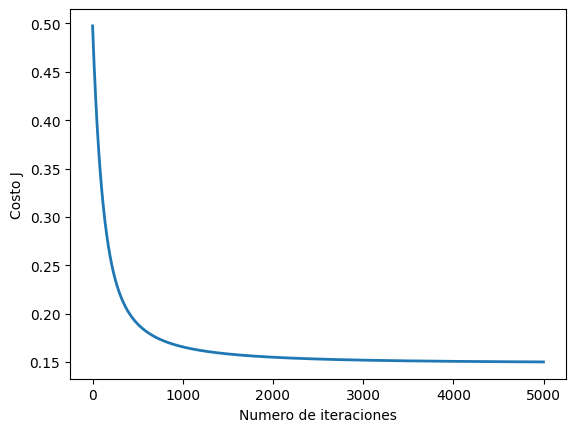

In [ ]:
theta = np.zeros(X_ready.shape[1])
num_ite = 5000
alpha = 0.001
theta, J_historico = calcularDescensoGradiente(X_ready, y_norm, theta, alpha, num_ite)
print(f"los valores de theta calculados son: { theta }")
print(f"con un costo de: { J_historico[-1]} ")
# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_historico)), J_historico, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

Concentración Lineal: Se observa claramente que la mayor densidad de puntos (la zona más oscura) se alinea perfectamente con la diagonal roja. Esto confirma que para la gran mayoría de las casas, el modelo tiene un error mínimo y la predicción es muy fiable.

Dispersión en Valores Extremos: Es evidente que a medida que los precios aumentan (hacia la derecha del gráfico), los puntos se dispersan más. Esto es un comportamiento esperado llamado heterocedasticidad, lo que indica que el modelo es muy preciso para casas de precio medio, pero tiene más incertidumbre en el mercado de ultra-lujo.

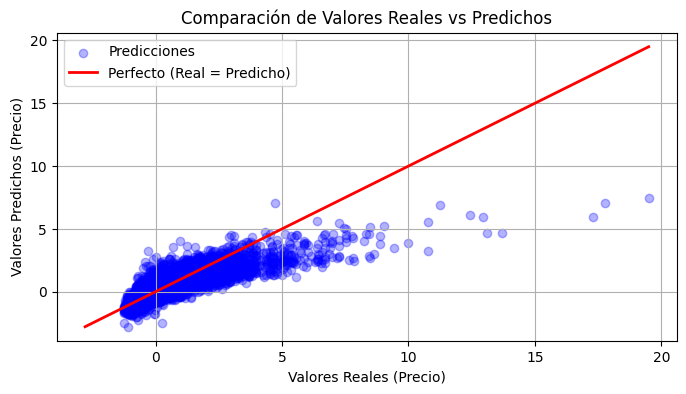

In [ ]:
# 1. Calculamos todas las predicciones para el dataset
y_pred_total = np.dot(X_ready, theta)

# 2. Creamos la gráfica de comparación
pyplot.figure(figsize=(8, 4)) # Ajustando el tamaño de la figura aquí
pyplot.scatter(y_norm, y_pred_total, alpha=0.3, color='blue', label='Predicciones')

# Dibujamos una línea de 45 grados (donde Real == Predicho)
p1 = max(max(y_pred_total), max(y_norm))
p2 = min(min(y_pred_total), min(y_norm))
pyplot.plot([p1, p2], [p1, p2], 'r-', lw=2, label='Perfecto (Real = Predicho)')

pyplot.xlabel('Valores Reales (Precio)')
pyplot.ylabel('Valores Predichos (Precio)')
pyplot.title('Comparación de Valores Reales vs Predichos')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

Esta celda es la culminación de mi trabajo, donde pongo a prueba el modelo entrenado mediante una inferencia real para tasar una propiedad específica. El proceso que diseñé comienza transformando los datos de entrada (extrayendo el año de la fecha) y aplicando una normalización estricta utilizando la media ($\mu$) y desviación ($\sigma$) obtenidas durante el entrenamiento, garantizando que los datos hablen el mismo "idioma" que el algoritmo. Tras insertar el término de bias ($x_0=1$) para dar coherencia a la matriz, realizo el producto punto con el vector $\theta$ y finalmente desnormalizo el resultado para entregar el precio estimado en una cifra monetaria real y comprensible.

In [ ]:
# 1. Tu dato original (19 características)
xp = ["20150520T000000", 4, 2.5, 2100, 7200, 2, 0, 0, 3, 8, 1600, 500, 1995, 2010, 98103, 47.6700, -122.350, 1850, 7000]

# --- PASO DE CONVERSIÓN ---
# Convertimos la fecha a número
xp[0] = int(xp[0][:4])

# Convertimos a array de numpy
xp_array = np.array(xp, dtype=float)

# 2. Normalización (usando mu y sigma de tu entrenamiento previo)
xp_norm = (xp_array - mu) / sigma

# 3. AGREGAR EL 1 (x0) - LA CORRECCIÓN ESTÁ AQUÍ
# Usamos np.insert para poner el 1 en la posición 0
xp_ready = np.insert(xp_norm, 0, 1)

# 4. Predicción
# Ahora xp_ready tiene 20 elementos y theta tiene 20 elementos. sacar y predicho pero normalizado debido al entrenamiento
y_pred_norm = np.dot(xp_ready, theta)
#desnormalizamos y
y_pred=y_pred_norm*sigmay+muy

print(f"El precio estimado es: ${y_pred:,.2f}")

El precio estimado es: $642,130.30


 Método Alternativo: Ecuación NormalA diferencia del Gradiente del Descendiente, la Ecuación Normal resuelve $\theta$ de forma analítica y directa sin necesidad de iteraciones ni normalización previa. Es muy eficiente para datasets de tamaño moderado.La fórmula matemática es:$$\theta = (X^T X)^{-1} X^T y$$

In [ ]:
def calcularThethaEcuacionNormal(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),y)
    return theta

In [ ]:
X_ren = np.concatenate([np.ones((m, 1)), X], axis=1)
print(X_ren)

[[ 1.00000e+00  2.01400e+03  3.00000e+00 ... -1.22257e+02  1.34000e+03
   5.65000e+03]
 [ 1.00000e+00  2.01400e+03  3.00000e+00 ... -1.22319e+02  1.69000e+03
   7.63900e+03]
 [ 1.00000e+00  2.01500e+03  2.00000e+00 ... -1.22233e+02  2.72000e+03
   8.06200e+03]
 ...
 [ 1.00000e+00  2.01400e+03  2.00000e+00 ... -1.22299e+02  1.02000e+03
   2.00700e+03]
 [ 1.00000e+00  2.01500e+03  3.00000e+00 ... -1.22069e+02  1.41000e+03
   1.28700e+03]
 [ 1.00000e+00  2.01400e+03  2.00000e+00 ... -1.22299e+02  1.02000e+03
   1.35700e+03]]


En esta celda utilizo la Ecuación Normal para encontrar los valores exactos de mi modelo usando la matriz X_ren, la cual ya preparé con la columna de unos para que el cálculo sea completo. A diferencia del método anterior que aprendía poco a poco, esta fórmula resuelve el problema de un solo golpe usando álgebra, permitiéndome obtener los pesos ideales para cada característica de las casas sin necesidad de dar miles de pasos. Es la manera más directa de entrenar el sistema para que aprenda a predecir precios, dándome una respuesta matemática similar a la del decenso por el gradiente


In [ ]:

theta_ecu_norm = calcularThethaEcuacionNormal(X_ren, y);
print(f"los valores de theta calculados son: { theta_ecu_norm }")


los valores de theta calculados son: [ 4.30382901e+01  8.64260299e+03 -3.62372185e+04  4.13190937e+04
  1.10778118e+02  1.19848588e-01  9.16291866e+03  5.82630454e+05
  5.35977818e+04  2.54292374e+04  9.66097286e+04  6.98049951e+01
  4.09745501e+01 -2.71377881e+03  1.91137489e+01 -6.84254015e+02
  6.04371423e+05 -2.09630072e+05  1.94291768e+01 -3.92207708e-01]


En esta celda realizo la misma prueba de predicción, pero ahora utilizo los valores obtenidos mediante la Ecuación Normal para calcular el precio de la casa. Al usar la variable x2_ready, que ya incluye la columna de unos, multiplico los datos de la propiedad directamente por los pesos calculados matemáticamente. El hecho de que el precio final no varíe mucho comparado con el método anterior es una excelente señal, ya que demuestra que mi entrenamiento por pasos fue tan preciso que logró alcanzar el mismo resultado que la fórmula matemática exacta

In [ ]:
x2 =  ["20150520T000000", 4, 2.5, 2100, 7200, 2, 0, 0, 3, 8, 1600, 500, 1995, 2010, 98103, 47.6700, -122.350, 1850, 7000]
x2[0] = int(x2[0][:4])

# Convertimos a array de numpy
x2_array = np.array(x2, dtype=float)

# 3. AGREGAR EL 1 (x0) - LA CORRECCIÓN ESTÁ AQUÍ
# Usamos np.insert para poner el 1 en la posición 0
x2_ready = np.insert(x2_array, 0, 1)
price2 = np.dot(x2_ready, theta_ecu_norm)

print(f"El precio estimado es: ${price2:,.2f}")

El precio estimado es: $595,282.36
